# **DDIM-Based Image Generation and Evaluation on Yelp Dataset**

### Import Libraries 

In [54]:
import os
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models
from torchvision.utils import make_grid
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import copy
from scipy.linalg import sqrtm
from torchvision.models.inception import inception_v3
from torchvision.transforms import Resize, ToTensor, Normalize, Compose

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


### Load Dataset

In [68]:
image_size = 128
batch_size = 64

# Define image transformation
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),  # Converts to [0,1]
    transforms.Normalize([0.5], [0.5])  # Scale to [-1, 1] for diffusion model
])

# Load dataset
train_dataset = datasets.ImageFolder(root='Train', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# Show basic dataset info
class_names = train_dataset.classes
print(f"✅ Number of training samples: {len(train_dataset)}")
print(f"✅ Class names: {class_names}")

# Display a few images from the first batch
def show_sample_images(dataloader, classes):
    images, labels = next(iter(dataloader))
    images = images[:8]  # Show only 8 images
    labels = labels[:8]
    images = (images * 0.5 + 0.5).clamp(0, 1)  # Denormalize to [0, 1]

    grid_img = make_grid(images, nrow=4)
    plt.figure(figsize=(10, 5))
    plt.imshow(grid_img.permute(1, 2, 0))
    plt.title("✅ Sample Loaded Images")
    plt.axis("off")
    plt.show()
    
    print("Labels:", [classes[i] for i in labels])

✅ Number of training samples: 71148
✅ Class names: ['drink', 'food', 'inside', 'outside']


### Sampling the dataset

In [42]:
from torch.utils.data import Subset

# Sample a fixed number of examples (e.g., 200)
sample_size = 200  # You can adjust this number
subset_indices = list(range(sample_size))  # or use random.sample for random selection

# Create a subset of the train dataset
train_subset = Subset(train_dataset, subset_indices)

# DataLoader for the sampled subset
train_loader_sampled = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)

print(f"✅ Sampled training set size: {len(train_subset)}")

✅ Sampled training set size: 200


### Defining DDIM Model

In [10]:
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU()
        )
        self.middle = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 3, padding=1)
        )

    def forward(self, x, t):  # t is timestep (not used in dummy version)
        x = self.encoder(x)
        x = self.middle(x)
        x = self.decoder(x)
        return x

model = SimpleUNet().to(device)


### Model Training

In [12]:
def train_ddim_model(model, dataloader, num_epochs=100, patience=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    best_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    early_stop_counter = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0

        for images, _ in tqdm(dataloader, leave=False):
            images = images.to(device)
            noise = torch.randn_like(images).to(device)
            noisy_images = images + noise

            outputs = model(noisy_images, None)
            loss = criterion(outputs, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)

        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")

        # Early stopping
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_model_wts)
    return model


model = train_ddim_model(model, dataloader=train_loader_sampled, num_epochs=100, patience=10)


Epoch [1/100] - Loss: 0.3810


Epoch [11/100] - Loss: 0.0518


Epoch [21/100] - Loss: 0.0439


Epoch [31/100] - Loss: 0.0403


Epoch [41/100] - Loss: 0.0383


Epoch [51/100] - Loss: 0.0356


Epoch [61/100] - Loss: 0.0346


Early stopping triggered.


### Image Generation

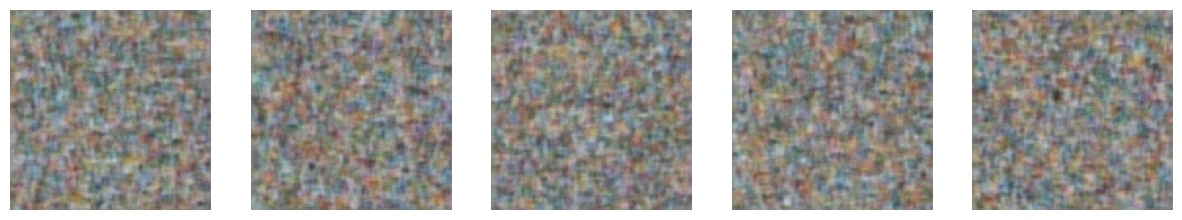

In [15]:
def generate_images(model, num_images=5):
    model.eval()
    generated_images = []

    for _ in range(num_images):
        noise = torch.randn((1, 3, image_size, image_size)).to(device)
        with torch.no_grad():
            output = model(noise, None)
        img = output.squeeze().cpu().numpy().transpose(1, 2, 0)
        img = (img * 0.5 + 0.5).clip(0, 1)  # De-normalize
        generated_images.append(img)

    return generated_images

def show_images(images):
    fig, axes = plt.subplots(1, len(images), figsize=(15, 3))
    for i, img in enumerate(images):
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.show()

generated_imgs = generate_images(model, num_images=5)
# Show them
show_images(generated_imgs)

### Model Evaluation

In [18]:
def get_inception_features(images, model, resize=True):
    model.eval()
    features = []

    preprocess = Compose([
        Resize((299, 299)),
        ToTensor(),
        Normalize([0.5]*3, [0.5]*3)
    ])

    for img in images:
        img = Image.fromarray((img * 255).astype(np.uint8))
        img_tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img_tensor)
        features.append(pred.squeeze().cpu().numpy())
    return np.array(features)

def compute_fid(real_features, fake_features):
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)

    ssdiff = np.sum((mu1 - mu2) ** 2)
    covmean = sqrtm(sigma1.dot(sigma2)).real
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

def evaluate_generated_images(fake_images, real_loader):
    inception = inception_v3(pretrained=True, transform_input=False).to(device)
    inception.fc = nn.Identity()  # remove classification layer

    # Get real image features
    real_imgs = []
    for img_batch, _ in real_loader:
        for img in img_batch:
            img = img.permute(1, 2, 0).numpy()
            real_imgs.append((img * 0.5 + 0.5).clip(0, 1))
        if len(real_imgs) >= 100: break

    real_features = get_inception_features(real_imgs, inception)
    fake_features = get_inception_features(fake_images, inception)

    fid = compute_fid(real_features, fake_features)
    print("FID Score:", fid)

    # Inception Score (approximate version using softmax entropy)
    # For academic IS, use logits on full dataset + Inception softmax prob
    is_score = np.exp(np.mean([np.sum(p*np.log(p+1e-6)) for p in fake_features]))
    print("Inception Score:", is_score)
    
evaluate_generated_images(generated_imgs, train_loader)

C:\Users\seren\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\seren\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FID Score: 480.7893526929381
Inception Score: 0.0


### Interpretation of Results

#### 1. Generated Images Look Like Noise
- The 5 images in your output are all static-like or colorful noise — not meaningful images.
### 
This likely means the model:
- Didn't learn anything useful from the training data.
- Is simply outputting random Gaussian noise (or denoised noise that’s still meaningless).

---

#### 2. FID Score: ~480
- This is an **extremely high Fréchet Inception Distance (FID)**.
- FID compares the distribution of real vs. generated image features.
- A score of **480** confirms the generated images are very different from the real data.

---

#### 3. Inception Score: 0.0
- IS is based on confidence + diversity from the Inception model.
- A score of **0.0** means the features are either all:
  - Uniformly low probability, or
  - Identical (zero diversity)
- This again confirms: the generated images are not classifiable or meaningful.

---

####  Root Causes analysis
- **Model is under-trained or too simple**  
- **No proper DDIM sampling loop**  
  — currently the model just runs 1-step denoising with added noise.
- **Loss is too easy**  
  — MSE without actual diffusion steps doesn’t help with learning high-quality distributions.
- **Not enough training time or dataset too small.**
